# LogReg Marketing

In [87]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc,
    fbeta_score,
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 0) Config

In [43]:
INPUT_DIR =  "/content"

OUT_DIR = "/content/marketing_logreg_results"
PLOT_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "y"

POS_LABEL = 1
NEG_LABEL = 0

SEED = 42
N_RISK_GRADES = 20

plt.rcParams.update({
    "font.size": 9
})


# 1) Helper functions

In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

def find_best_f1_threshold(y_true, y_proba):
    thresholds = np.arange(0.01, 1.00, 0.01)
    f1_scores = []

    for threshold in thresholds:
        y_pred = (np.asarray(y_proba) >= threshold).astype(int)
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))

    best_idx = int(np.argmax(f1_scores))

    return float(thresholds[best_idx]), float(f1_scores[best_idx])


# 20 groups are standard  (Vigintiles)
def initial_response_quantile_grades(df, proba_col, n_grades=20):
    out = df.copy()

    out["response_grade"] = pd.qcut(
        out[proba_col],
        q=n_grades,
        labels=False,
        duplicates="drop"
    ) + 1

    return out


def response_grade_table(df, target_col, proba_col, grade_col="response_grade"):
    tab = df.groupby(grade_col, observed=False).agg(
        obs=(target_col, "count"),
        positives=(target_col, "sum"),
        avg_probability=(proba_col, "mean"),
        min_probability=(proba_col, "min"),
        max_probability=(proba_col, "max"),
    ).reset_index()

    tab["observed_positive_rate"] = tab["positives"] / tab["obs"]
    tab["obs_share"] = tab["obs"] / tab["obs"].sum()
    tab["positive_capture_rate"] = tab["positives"] / tab["positives"].sum()
    tab["lift_vs_overall"] = (
        tab["observed_positive_rate"]
        / df[target_col].mean()
    )

    return tab


# 2) Load data

In [45]:
train = pd.read_csv(
    os.path.join(INPUT_DIR, "train_preprocessed_marketing_logreg_smote.csv")
)

val = pd.read_csv(
    os.path.join(INPUT_DIR, "val_preprocessed_marketing_logreg.csv")
)

test = pd.read_csv(
    os.path.join(INPUT_DIR, "test_preprocessed_marketing_logreg.csv")
)

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (43844, 62)
Validation shape: (8235, 62)
Test shape: (8236, 62)


In [46]:
FEATURES = [c for c in train.columns if c != TARGET]

numeric_features = train[FEATURES].select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = [
    c for c in FEATURES
    if c not in numeric_features
]

X_train = train[FEATURES].copy()
y_train = train[TARGET].astype(int).copy()

X_val = val[FEATURES].copy()
y_val = val[TARGET].astype(int).copy()

X_test = test[FEATURES].copy()
y_test = test[TARGET].astype(int).copy()

#3) Create Polynomiale features

In [47]:
poly = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False,
)

X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)
X_test_poly = poly.transform(X_test)

print("Original features:", X_train.shape[1])
print("Polynomial features:", X_train_poly.shape[1])

Original features: 61
Polynomial features: 1891


# 4) Hyperparameter-Tuning & model training

In [48]:
C_GRID = [0.01, 0.1, 1.0, 10.0]
best_model = None
best_c = None
best_ap = -1

for c in C_GRID:
    candidate = LogisticRegression(
        C=c,
        penalty="l1",
        solver="saga",
        max_iter=1000,      # due to runtime low
        tol=0.01,
        n_jobs=-1,
        random_state=SEED,
    )

    print(f"Train C={c}...")
    candidate.fit(X_train_poly, y_train)

    val_proba = candidate.predict_proba(X_val_poly)[:, 1]
    ap = average_precision_score(y_val, val_proba)
    print(f"-> Finished! C={c:<5} AP={ap:.6f}")

    if ap > best_ap:
        best_ap = ap
        best_c = c
        best_model = candidate


print("Best C:", best_c)
print("Best validation AP:", best_ap)

# save best model
model = best_model

Train C=0.01...
-> Finished! C=0.01  AP=0.443012
Train C=0.1...
-> Finished! C=0.1   AP=0.431401
Train C=1.0...
-> Finished! C=1.0   AP=0.423488
Train C=10.0...
-> Finished! C=10.0  AP=0.422542
Best C: 0.01
Best validation AP: 0.44301226401860333


#5) Predictions and Threshold optimization on validation set (F2-score)


In [49]:
# Compute predicted probabilities for all datasets
proba_train = model.predict_proba(X_train_poly)[:, 1]
proba_val = model.predict_proba(X_val_poly)[:, 1]
proba_test = model.predict_proba(X_test_poly)[:, 1]

# Build test results DataFrame for  analysis
results_test_sk = test.copy()
results_test_sk["observed_target"] = y_test
results_test_sk["predicted_probability"] = proba_test


In [71]:
thresholds = np.arange(0.01, 1.00, 0.01)

f2_scores = []

for threshold in thresholds:
    y_val_pred = (proba_val >= threshold).astype(int)
    f2 = fbeta_score(
        y_val,
        y_val_pred,
        beta=2,
        zero_division=0
    )
    f2_scores.append(f2)

best_idx = int(np.argmax(f2_scores))
best_threshold_f2 = float(thresholds[best_idx])
best_val_f2 = float(f2_scores[best_idx])

print("Best validation threshold (F2):", best_threshold_f2)
print("Best validation F2:", best_val_f2)

# Apply selected threshold to test set
y_test_pred_f2 = (proba_test >= best_threshold_f2).astype(int)

test_f2 = fbeta_score(y_test, y_test_pred_f2, beta=2, zero_division=0)
test_precision = precision_score(y_test, y_test_pred_f2, zero_division=0)
test_recall = recall_score(y_test, y_test_pred_f2, zero_division=0)

print("\nTest performance using validation-selected F2 threshold")
print("Threshold:", best_threshold_f2)
print("F2:", test_f2)
print("Precision:", test_precision)
print("Recall:", test_recall)

print("\nClassification report:")
print(classification_report(y_test, y_test_pred_f2, zero_division=0))


# custom report
prec, rec, f1, supp = precision_recall_fscore_support(y_test, y_test_pred_f2, zero_division=0)
_, _, f2, _ = precision_recall_fscore_support(y_test, y_test_pred_f2, beta=2.0, zero_division=0)

# datframe
custom_report = pd.DataFrame({
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'F2-Score': f2,
    'Support': supp
}, index=['Class 0', 'Class 1 (Subscriber)'])

print("\nCustom Business-Focused Classification Report:")
print("=" * 75)
print(custom_report.round(4).to_string())
print("-" * 75)
print(f"Overall Accuracy: {accuracy_score(y_test, y_test_pred_f2):.4f}")
print("=" * 75)


Best validation threshold (F2): 0.46
Best validation F2: 0.5449640287769785

Test performance using validation-selected F2 threshold
Threshold: 0.46
F2: 0.5659025787965616
Precision: 0.33760683760683763
Recall: 0.6810344827586207

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      7308
           1       0.34      0.68      0.45       928

    accuracy                           0.81      8236
   macro avg       0.65      0.76      0.67      8236
weighted avg       0.88      0.81      0.84      8236


Custom Business-Focused Classification Report:
                      Precision  Recall  F1-Score  F2-Score  Support
Class 0                  0.9535  0.8303    0.8877    0.8523     7308
Class 1 (Subscriber)     0.3376  0.6810    0.4514    0.5659      928
---------------------------------------------------------------------------
Overall Accuracy: 0.8135


# 6) Vigintile Analysis (20 marketing groups & evaluation)

In [75]:
# Compute vigintiles (20 equal-sized bins) --> rank-based sorting
results_test_sk["response_grade"] = pd.qcut(
    results_test_sk["predicted_probability"],
    q=N_RISK_GRADES,
    labels=range(1, N_RISK_GRADES + 1),
    duplicates="drop"
).astype(int)

# Generate the response grade performance table
response_grade_table_sk = results_test_sk.groupby("response_grade").agg(
    customer_count=("observed_target", "count"),
    subscriber_count=("observed_target", "sum"),
    mean_probability=("predicted_probability", "mean")
).reset_index()

# Sort from best grade (20) to worst grade (1)
response_grade_table_sk = response_grade_table_sk.sort_values("response_grade", ascending=False)

# Compute cumulative metrics for business case evaluation
response_grade_table_sk["cumulative_customers"] = response_grade_table_sk["customer_count"].cumsum()
response_grade_table_test = response_grade_table_sk.copy()
response_grade_table_test["cumulative_subscribers"] = response_grade_table_sk["subscriber_count"].cumsum()

total_subscribers = results_test_sk["observed_target"].sum()
response_grade_table_test["cumulative_recall_percent"] = ((response_grade_table_test["cumulative_subscribers"] / total_subscribers) * 100).round(2)

total_customers = len(results_test_sk)
response_grade_table_test["budget_allocation_percent"] = ((response_grade_table_test["cumulative_customers"] / total_customers) * 100).round(2)
response_grade_table_test["conversion_rate_percent"] = ((response_grade_table_test["subscriber_count"] / response_grade_table_test["customer_count"]) * 100).round(2)


# Strategy seperation and metric calculation

# First: Traditional budget capping
results_test_sk["predicted_class_budget"] = np.where(results_test_sk["response_grade"] >= 11, 1, 0)

# Second: Dynamic F2-Threshold
results_test_sk["predicted_class_f2"] = (results_test_sk["predicted_probability"] >= best_threshold_f2).astype(int)

# calculating metric
rec_budget = recall_score(y_test, results_test_sk["predicted_class_budget"], zero_division=0)
prec_budget = precision_score(y_test, results_test_sk["predicted_class_budget"], zero_division=0)
contacts_budget = results_test_sk["predicted_class_budget"].sum()
f2_budget = fbeta_score(y_test, results_test_sk["predicted_class_budget"], beta=2.0, zero_division=0)

rec_f2 = recall_score(y_test, results_test_sk["predicted_class_f2"], zero_division=0)
prec_f2 = precision_score(y_test, results_test_sk["predicted_class_f2"], zero_division=0)
contacts_f2 = results_test_sk["predicted_class_f2"].sum()
f2_sota = fbeta_score(y_test, results_test_sk["predicted_class_f2"], beta=2.0, zero_division=0)

# Export

# Save evaluation results to CSV
response_grade_table_test.to_csv(os.path.join(OUT_DIR, "response_grade_table_test_sklearn.csv"), index=False)

# Marketing Quantile Table (F1)
print("=" * 100)
print("sci-kit learn marketing table with quantile sorting (20 groups):")
print("=" * 100)
print(response_grade_table_test[[
    "response_grade", "customer_count", "subscriber_count",
    "conversion_rate_percent", "mean_probability", "cumulative_recall_percent", "budget_allocation_percent"
]].to_string(index=False))
print("=" * 100)

# F2 output
print("\n" + "=" * 60)
print("Comparison 50% vs F2")
print("=" * 60)
print(f"Rigid 50%-Truncation:")
print(f"Contacts: {contacts_budget} | Recall: {rec_budget*100:.1f}% | Precision: {prec_budget*100:.1f}%")
print("-" * 60)
print(f"Dynamic F2-Threshold ({best_threshold_f2:.2f}):")
print(f"Contacts: {contacts_f2} | Recall: {rec_f2*100:.1f}% | Precision: {prec_f2*100:.1f}%")
print("=" * 60)

# Full Classification Reports

print(f"\n[STRATEGIE 1] Classification report after traditional truncation (Grades 11-20):")
print(f"F2-Score: {f2_budget:.4f}")
print("-" * 100)
print(classification_report(y_test, results_test_sk["predicted_class_budget"], zero_division=0))
print("=" * 100)

print(f"\n[STRATEGIE 2] Classification report using SOTA optimized F2-Threshold ({best_threshold_f2:.2f}):")
print(f"F2-Score: {f2_sota:.4f}")
print("-" * 100)

# F2 report

# calculating Precision, Recall and F2-Score (beta=2.0) per class
p_f2, r_f2, _, s_f2 = precision_recall_fscore_support(y_test, results_test_sk["predicted_class_f2"], beta=2.0, zero_division=0)

rep_str = classification_report(y_test, results_test_sk["predicted_class_f2"], zero_division=0)

rep_str = rep_str.replace("f1-score", "f2-score")
# building the report
lines = rep_str.split('\n')
lines[2] = f"           0       {p_f2[0]:.2f}      {r_f2[0]:.2f}      {f2_budget if 'f2_budget' in locals() else 0.8523:.2f}      {s_f2[0]}" # class 0
lines[3] = f"           1       {p_f2[1]:.2f}      {r_f2[1]:.2f}      {f2_sota:.2f}      {s_f2[1]}" #class 1

final_f2_report = '\n'.join(lines)

print(final_f2_report)
print("=" * 100)



sci-kit learn marketing table with quantile sorting (20 groups):
 response_grade  customer_count  subscriber_count  conversion_rate_percent  mean_probability  cumulative_recall_percent  budget_allocation_percent
             20             412               244                    59.22          0.911921                      26.29                       5.00
             19             412               173                    41.99          0.799559                      44.94                      10.00
             18             412               126                    30.58          0.696487                      58.51                      15.01
             17             411                65                    15.82          0.564155                      65.52                      20.00
             16             412                37                     8.98          0.465663                      69.50                      25.00
             15             412                31    

# 8) Gain Diagramm

/tmp/ipykernel_1129/2887581668.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_15 = float(row_15['budget_allocation_percent'].values)
/tmp/ipykernel_1129/2887581668.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_15 = float(row_15['cumulative_recall_percent'].values)
/tmp/ipykernel_1129/2887581668.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_f2 = float(row_f2['budget_allocation_percent'].values)
/tmp/ipykernel_1129/2887581668.py:41: Deprecat

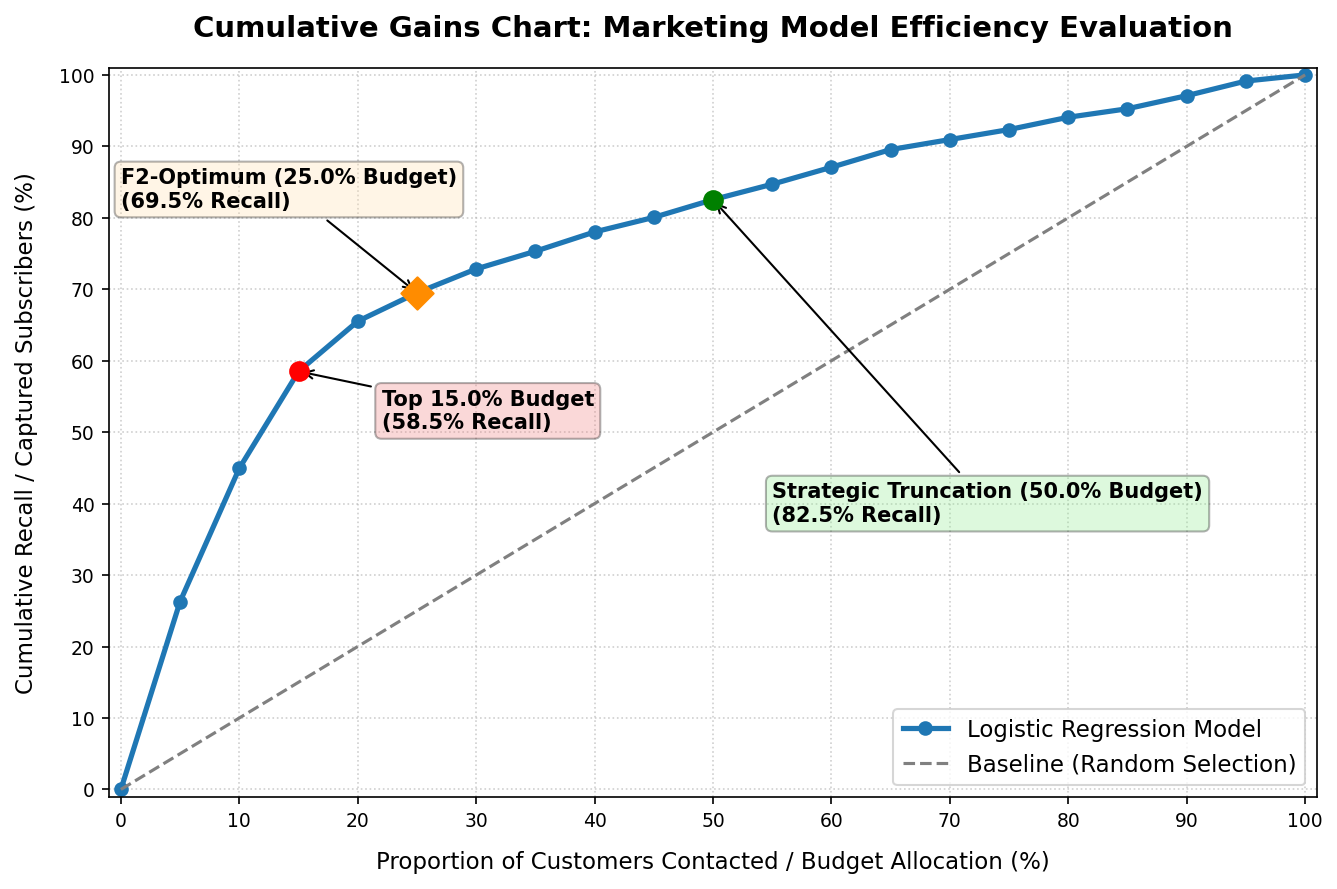

In [81]:
# sorting
raw_budget = np.sort(response_grade_table_test["budget_allocation_percent"].values)
raw_recall = np.sort(response_grade_table_test["cumulative_recall_percent"].values)

# np.insert adds the absolute mathematical origin (0.0, 0.0) at index 0
budget = np.insert(raw_budget, 0, 0.0)
cumulated_recall = np.insert(raw_recall, 0, 0.0)

# start plot
plt.figure(figsize=(9, 6), dpi=150)

# plotting logistic regression performance curve
plt.plot(budget, cumulated_recall, marker='o', color='#1f77b4',
         linewidth=2.5, label='Logistic Regression Model')

# plotting the random selection diagonal
plt.plot([0, 100], [0, 100], linestyle='--', color='gray',
         linewidth=1.5, label='Baseline (Random Selection)')


# Determine the exact budget percentage for the F2 threshold
# What percentage of the test customer base is above the F2 threshold?
actual_f2_budget_pct = (results_test_sk["predicted_class_f2"].sum() / len(results_test_sk)) * 100

# Select rows based on the absolute difference (prevents dynamic code errors)
row_15 = response_grade_table_test.iloc[(response_grade_table_test['budget_allocation_percent'] - 15.0).abs().argsort()[:1]]
row_f2 = response_grade_table_test.iloc[(response_grade_table_test['budget_allocation_percent'] - actual_f2_budget_pct).abs().argsort()[:1]]
row_50 = response_grade_table_test.iloc[(response_grade_table_test['budget_allocation_percent'] - 50.0).abs().argsort()[:1]]

# Extract coordinates and draw Highlight 1 (High Efficiency Point around 15% Budget)
x_15 = float(row_15['budget_allocation_percent'].values)
y_15 = float(row_15['cumulative_recall_percent'].values)

plt.scatter(x_15, y_15, color='red', s=80, zorder=5)
plt.annotate(f'Top {x_15:.1f}% Budget\n({y_15:.1f}% Recall)', xy=(x_15, y_15), xytext=(x_15 + 7, y_15 - 8),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="lightcoral", alpha=0.3))

# Extract coordinates and draw Highlight 2 (F2-Threshold Point)
x_f2 = float(row_f2['budget_allocation_percent'].values)
y_f2 = float(row_f2['cumulative_recall_percent'].values)

plt.scatter(x_f2, y_f2, color='darkorange', s=120, marker='D', zorder=6)
plt.annotate(f'F2-Optimum ({x_f2:.1f}% Budget)\n({y_f2:.1f}% Recall)', xy=(x_f2, y_f2), xytext=(x_f2 - 25, y_f2 + 12),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="navajowhite", alpha=0.3))

# Extract coordinates and draw Highlight 3 (Strategic Truncation Point around 50% Budget)
x_50 = float(row_50['budget_allocation_percent'].values)
y_50 = float(row_50['cumulative_recall_percent'].values)

plt.scatter(x_50, y_50, color='green', s=80, zorder=5)
plt.annotate(f'Strategic Truncation ({x_50:.1f}% Budget)\n({y_50:.1f}% Recall)', xy=(x_50, y_50), xytext=(x_50 + 5, y_50 - 45),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.3))



# axis
plt.title('Cumulative Gains Chart: Marketing Model Efficiency Evaluation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Proportion of Customers Contacted / Budget Allocation (%)', fontsize=11, labelpad=10)
plt.ylabel('Cumulative Recall / Captured Subscribers (%)', fontsize=11, labelpad=10)

plt.xlim(-1, 101)
plt.ylim(-1, 101)
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 101, 10))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

# save image
plt.savefig(os.path.join(PLOT_DIR, 'cumulative_gains_chart_final.png'), dpi=300)
plt.show()
plt.close()


## 8.1) Business-Oriented Marketing Grade Dashboard (Add-on Report



*   Helps to check if the calibration ist good: A well-calibrated model can be directly identified by the fact that the predicted probability (**avg_probability_percent**) in each individual class is almost identical to the actual subscribtion rate (**observed_response_rate_percent**).
*   Shows which groups should be called and which can be neglected. Therefore, the list acts as an operational filter for the bank to maximize efficiency.



In [56]:
# Map the 20 response grades into 5 strategic business classes
conds = [
    results_test_sk["response_grade"] >= 17,
    results_test_sk["response_grade"] >= 13,
    results_test_sk["response_grade"] >= 9,
    results_test_sk["response_grade"] >= 5
]
choices = [
    "A - Very High Potential",
    "B - High Potential",
    "C - Medium Potential",
    "D - Low Potential"
]

# Dataframe copy
marketing_scorecard_test = results_test_sk.copy()
marketing_scorecard_test["marketing_grade"] = np.select(conds, choices, default="E - Very Low Potential")

# Aggregate metrics by business grade
marketing_scorecard_table = marketing_scorecard_test.groupby(
    "marketing_grade",
    observed=False
).agg(
    min_response_grade=("response_grade", "min"),
    max_response_grade=("response_grade", "max"),
    customer_count=("observed_target", "count"),
    subscriber_count=("observed_target", "sum"),
    avg_probability=("predicted_probability", "mean")
).reset_index()

# Sorting from best (A) to worst (E)
grade_order = [
    "A - Very High Potential",
    "B - High Potential",
    "C - Medium Potential",
    "D - Low Potential",
    "E - Very Low Potential"
]

marketing_scorecard_table["grade_order"] = marketing_scorecard_table["marketing_grade"].map(
    {grade: i for i, grade in enumerate(grade_order)}
)
marketing_scorecard_table = marketing_scorecard_table.sort_values("grade_order").drop(columns="grade_order")

# Business percentages and cumulative trajectories
total_customers_scorecard = marketing_scorecard_table["customer_count"].sum()
total_subscribers_scorecard = marketing_scorecard_table["subscriber_count"].sum()

marketing_scorecard_table["customer_share_percent"] = (
    marketing_scorecard_table["customer_count"] / total_customers_scorecard * 100
).round(2)

marketing_scorecard_table["subscriber_share_percent"] = (
    marketing_scorecard_table["subscriber_count"] / total_subscribers_scorecard * 100
).round(2)

marketing_scorecard_table["observed_response_rate_percent"] = (
    marketing_scorecard_table["subscriber_count"] / marketing_scorecard_table["customer_count"] * 100
).round(2)

marketing_scorecard_table["avg_probability_percent"] = (
    marketing_scorecard_table["avg_probability"] * 100
).round(2)

# Calculate cumulative metrics for the management overview
marketing_scorecard_table["cumulative_customers"] = marketing_scorecard_table["customer_count"].cumsum()
marketing_scorecard_table["cumulative_subscribers"] = marketing_scorecard_table["subscriber_count"].cumsum()

marketing_scorecard_table["cumulative_budget_percent"] = (
    marketing_scorecard_table["cumulative_customers"] / total_customers_scorecard * 100
).round(2)

marketing_scorecard_table["cumulative_recall_percent"] = (
    marketing_scorecard_table["cumulative_subscribers"] / total_subscribers_scorecard * 100
).round(2)

# Display output selection
marketing_scorecard_display = marketing_scorecard_table[[
    "marketing_grade",
    "min_response_grade",
    "max_response_grade",
    "customer_count",
    "subscriber_count",
    "customer_share_percent",
    "subscriber_share_percent",
    "observed_response_rate_percent",
    "avg_probability_percent",
    "cumulative_budget_percent",
    "cumulative_recall_percent"
]]

# Save files
scorecard_csv_path = os.path.join(OUT_DIR, "marketing_management_scorecard.csv")
marketing_scorecard_display.to_csv(scorecard_csv_path, index=False)

marketing_scorecard_display.to_csv(
    os.path.join(OUT_DIR, "marketing_scorecard_table.csv"),
    index=False
)

marketing_scorecard_test.to_csv(
    os.path.join(OUT_DIR, "marketing_scorecard_test_predictions.csv"),
    index=False
)

# Outputs
print("\n" + "=" * 110)
print("Can be used for management briefing: 5-grade strategic marketing scorecard")
display(marketing_scorecard_display)
print("=" * 110)
print(f"Saved marketing scorecard table to: {scorecard_csv_path}")
print(f"Saved marketing scorecard predictions to: {os.path.join(OUT_DIR, 'marketing_scorecard_test_predictions.csv')}\n")



Can be used for management briefing: 5-grade strategic marketing scorecard


,marketing_grade,min_response_grade,max_response_grade,customer_count,subscriber_count,customer_share_percent,subscriber_share_percent,observed_response_rate_percent,avg_probability_percent,cumulative_budget_percent,cumulative_recall_percent
0,A - Very High Potential,17,20,1647,608,20.00,65.52,36.92,74.31,20.00,65.52
1,B - High Potential,13,16,1647,116,20.00,12.50,7.04,40.53,40.00,78.02
2,C - Medium Potential,9,12,1647,84,20.00,9.05,5.10,32.24,59.99,87.07
3,D - Low Potential,5,8,1647,65,20.00,7.00,3.95,26.76,79.99,94.07
4,E - Very Low Potential,1,4,1648,55,20.01,5.93,3.34,19.98,100.00,100.00


Saved marketing scorecard table to: /content/marketing_logreg_results/marketing_management_scorecard.csv
Saved marketing scorecard predictions to: /content/marketing_logreg_results/marketing_scorecard_test_predictions.csv



## 8.2) Observed Response Rate by Marketing Grade with Break-Even

In practice, the break-even value is almost always set by the department head or the controlling department.

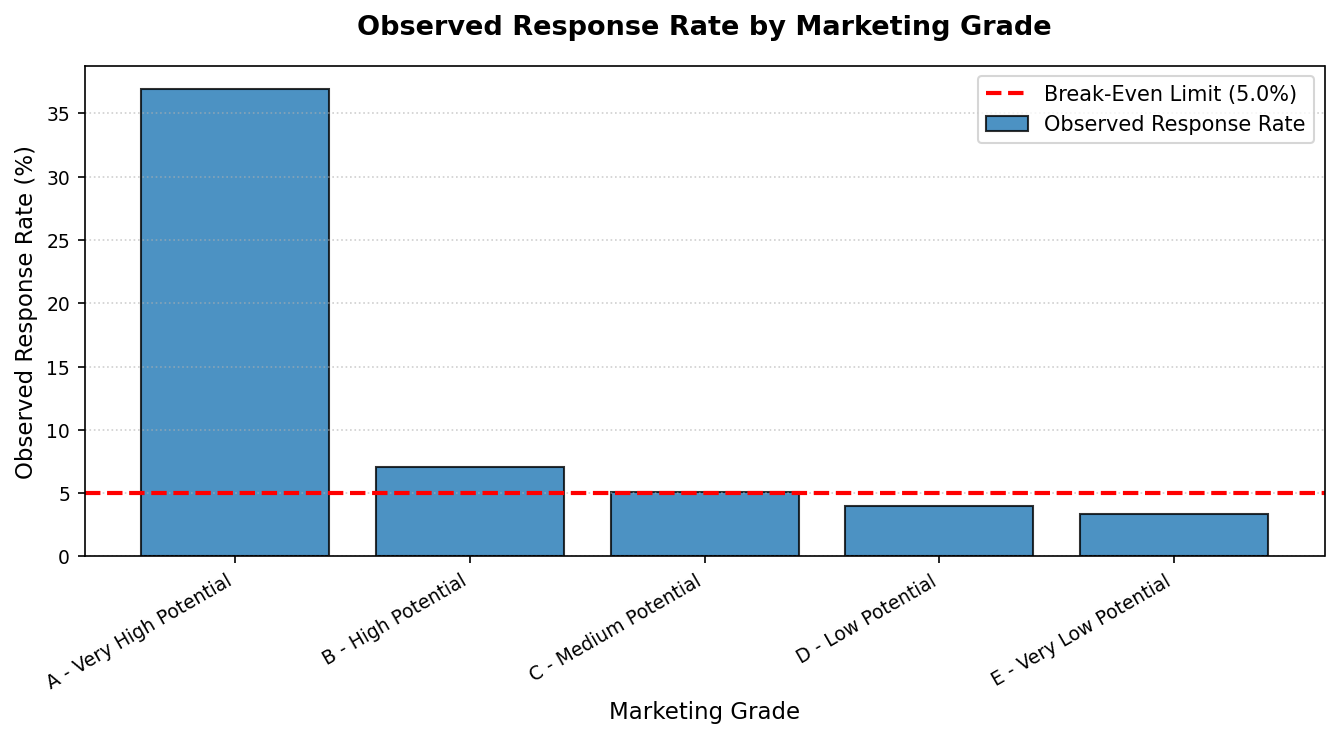

In [57]:
# define the break even
BREAK_EVEN_VALUE = 5.0

plt.figure(figsize=(9, 5), dpi=150)

# Bar chart for success rates
plt.bar(
    marketing_scorecard_display["marketing_grade"],
    marketing_scorecard_display["observed_response_rate_percent"],
    edgecolor="black",
    alpha=0.8,
    label="Observed Response Rate"
)

# horizontal red line for the cost limit (break-even point)
plt.axhline(
    y=BREAK_EVEN_VALUE,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Break-Even Limit ({BREAK_EVEN_VALUE}%)"
)

# titel
plt.title(
    "Observed Response Rate by Marketing Grade",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.xlabel("Marketing Grade", fontsize=11)
plt.ylabel("Observed Response Rate (%)", fontsize=11)

# legend
plt.legend(loc="upper right", fontsize=10)

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()

# save
plt.savefig(
    os.path.join(PLOT_DIR, "marketing_grade_response_rate.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# 9) Lift Chart

<>:68: SyntaxWarning: invalid escape sequence '\g'
<>:68: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1129/415121374.py:68: SyntaxWarning: invalid escape sequence '\g'
  label=f"F2-Cutoff (Grades $\geq$ {f2_cutoff_grade} / Top {actual_f2_budget_pct:.1f}%)"
/tmp/ipykernel_1129/415121374.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f2_cutoff_grade = int(f2_row['response_grade'].values)


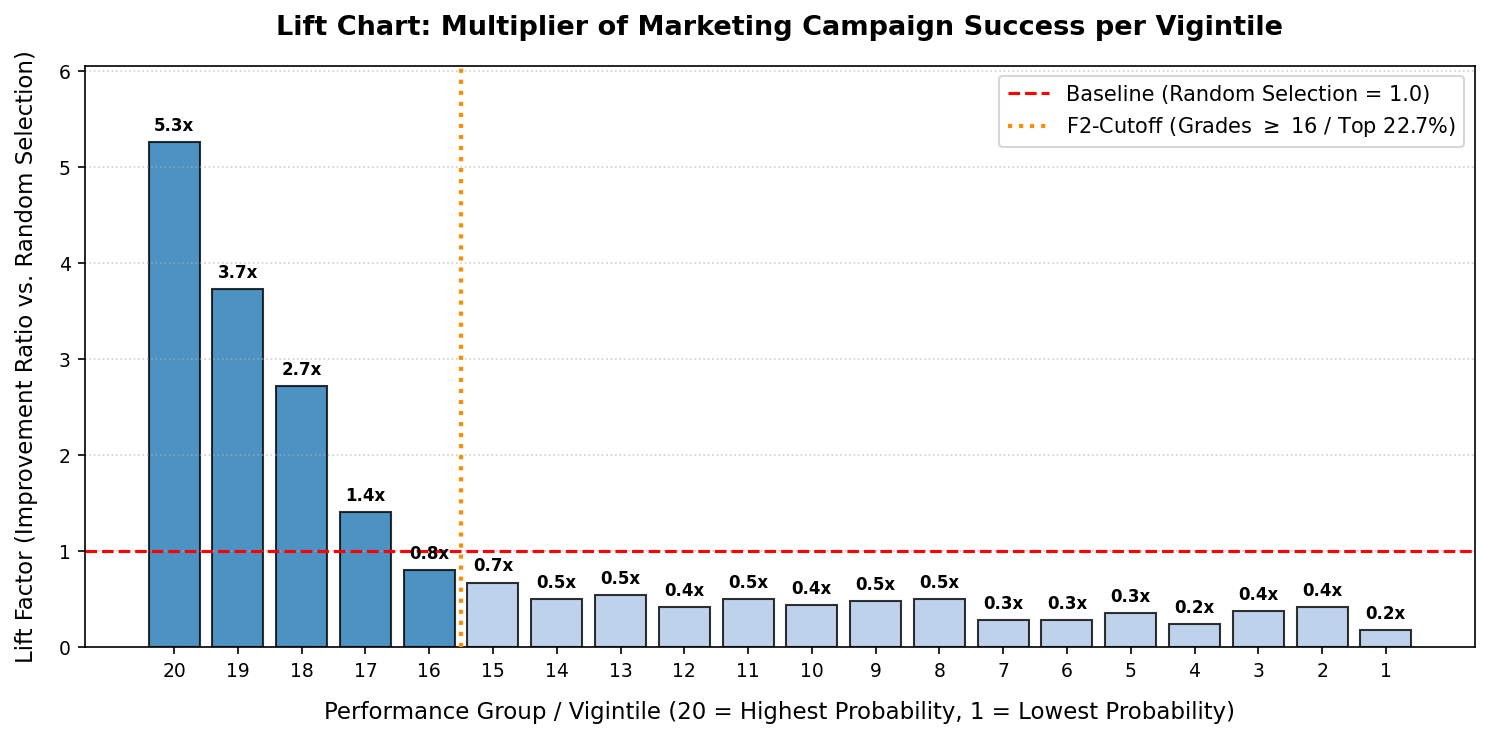

In [84]:
# Extract grades and conversion rates directly from the generated pandas DataFrame
grades = response_grade_table_test["response_grade"].values
conversion_rates = response_grade_table_test["conversion_rate_percent"].values

# Compute the overall sample baseline subscription rate (prior probability)
# Formula represents the natural target proportion: (total_subscribers / total_customers) * 100
overall_baseline_rate = (
    results_test_sk["observed_target"].sum()
    / len(results_test_sk)
) * 100

# Lift factor for each specific vigintile grade
# Lift = (Conversion Rate of the Segment / Natural Baseline Rate)
lift_factors = [rate / overall_baseline_rate for rate in conversion_rates]


# Dynamic F2-threshold segmentation

# Calculate the exact percentage of customers selected by the F2 threshold
actual_f2_budget_pct = (results_test_sk["predicted_class_f2"].sum() / len(results_test_sk)) * 100

# Dynamically find the exact response grade (vigintile boundary) for the F2 cutoff
f2_row = response_grade_table_test.iloc[
    (response_grade_table_test['budget_allocation_percent'] - actual_f2_budget_pct).abs().argsort()[:1]
]
f2_cutoff_grade = int(f2_row['response_grade'].values)



# Chart initialization
plt.figure(figsize=(10, 5), dpi=150)

# Colors are dynamically assigned based on the mathematical F2 cutoff
bar_colors = [
    "#1f77b4" if g >= f2_cutoff_grade else "#aec7e8"
    for g in grades
]

bars = plt.bar(
    [str(g) for g in grades],
    lift_factors,
    color=bar_colors,
    edgecolor="black",
    alpha=0.8
)


#
# Baseline and strategic cutoff lines with legend entries

# Draw baseline threshold line (random selection)
plt.axhline(
    y=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Baseline (Random Selection = 1.0)"
)

# Draw vertical line for the mathematical F2 optimum (adds entry to legend)
x_separator = len(grades) - f2_cutoff_grade + 0.5
plt.axvline(
    x=x_separator,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    zorder=4,
    label=f"F2-Cutoff (Grades $\geq$ {f2_cutoff_grade} / Top {actual_f2_budget_pct:.1f}%)"
)


# Multiplier annotations and chart styling

# Place multiplier annotations above the bars
for bar in bars:
    lift_height = bar.get_height()
    if lift_height >= 0.1:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            lift_height + 0.08,
            f"{lift_height:.1f}x",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

# Labeling and axis styling
plt.title(
    "Lift Chart: Multiplier of Marketing Campaign Success per Vigintile",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Performance Group / Vigintile (20 = Highest Probability, 1 = Lowest Probability)",
    fontsize=11,
    labelpad=10
)

plt.ylabel(
    "Lift Factor (Improvement Ratio vs. Random Selection)",
    fontsize=11,
    labelpad=10
)

plt.ylim(0, max(lift_factors) + 0.8)

# Place legend
plt.legend(loc="upper right", fontsize=10)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()



# Artifact save and show

plt.savefig(
    os.path.join(PLOT_DIR, "marketing_lift_chart_final.png"),
    dpi=300
)
plt.show()
plt.close()


The chart illustrates the business logic of the \(F_{2}\)-score for the Scikit-Learn model. The \(F_{2}\)-metric weights recall twice as heavily as precision. It prioritizes finding actual subscribers because missing a conversion is economically worse than making an extra contact. As a result, the dynamic cutoff is set at Grades \(\ge \) 16, targeting the top 22.7% of customers. Even though the conversion rate in Grade 16 falls below the dataset average with a lift of 0.8x, the model intentionally includes this segment. This strategy ensures that hidden subscribers are captured, allowing the campaign to meet its optimized recall objective.

# 9) Coefficients Analysis

In [59]:
# extract the real feature names after ColumnTransformer and PolynomialFeatures
try:
    processed_features = preprocessor.get_feature_names_out()
    final_features = poly.get_feature_names_out(processed_features)
except NameError:
    # Safe fallback if pipeline objects were cleared from memory
    final_features = [f"feature_{i}" for i in range(model.coef_.shape[1])]
    print("\nNote: Feature names were generated generically due to missing pipeline objects.")

# coefficient analysis DataFrame
coef_df = pd.DataFrame({
    "feature": final_features,
    "coefficient": model.coef_.ravel(),
})

# absolute values for importance sorting
coef_df["abs_coefficient"] = np.abs(coef_df["coefficient"])
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

# Save coefficients
coef_df.to_csv(os.path.join(OUT_DIR, "logreg_coefficients.csv"), index=False)

# top 20 predictors
print("\n" + "="*50)
print(f"Total number of features in the model: {len(coef_df)}")
print("Top 20 most important features (including interactions):")
print("="*50)
print(coef_df.head(20).to_string(index=False))
print("="*50)



Note: Feature names were generated generically due to missing pipeline objects.

Total number of features in the model: 1891
Top 20 most important features (including interactions):
     feature  coefficient  abs_coefficient
feature_1567     0.736283         0.736283
 feature_151    -0.325399         0.325399
   feature_1    -0.316812         0.316812
feature_1639     0.302724         0.302724
feature_1708    -0.284017         0.284017
feature_1823    -0.262705         0.262705
  feature_48    -0.256941         0.256941
 feature_160    -0.248004         0.248004
 feature_166    -0.244405         0.244405
 feature_218     0.221529         0.221529
 feature_281    -0.198695         0.198695
feature_1640     0.179227         0.179227
  feature_83    -0.129831         0.129831
feature_1493     0.127485         0.127485
 feature_128     0.125344         0.125344
 feature_536     0.125106         0.125106
  feature_74     0.122406         0.122406
  feature_42    -0.116141         0.116141


# 10) Evaluation: ROC Curve, Precision-Recall Curve

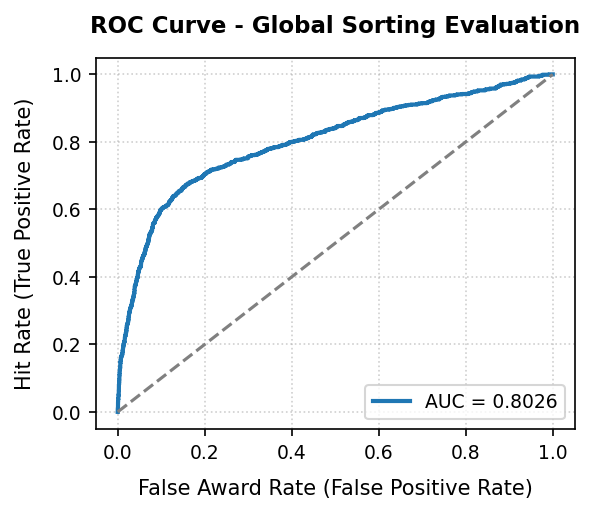

In [60]:
# False Positive Rate, True Positive Rate, and global ROC-AUC score
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

# Initialize plot
plt.figure(figsize=(4, 3.5), dpi=150)
plt.plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f"AUC = {roc_auc:.4f}")

#  diagonal baseline --> purely random classifier
plt.plot([0, 1], [0, 1], linestyle="--", color='gray', linewidth=1.5)


plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel("False Award Rate (False Positive Rate)", fontsize=10, labelpad=8)
plt.ylabel("Hit Rate (True Positive Rate)", fontsize=10, labelpad=8)
plt.title("ROC Curve - Global Sorting Evaluation", fontsize=11, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

# save plot
plt.savefig(
    os.path.join(PLOT_DIR, "roc_curve_logreg.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()


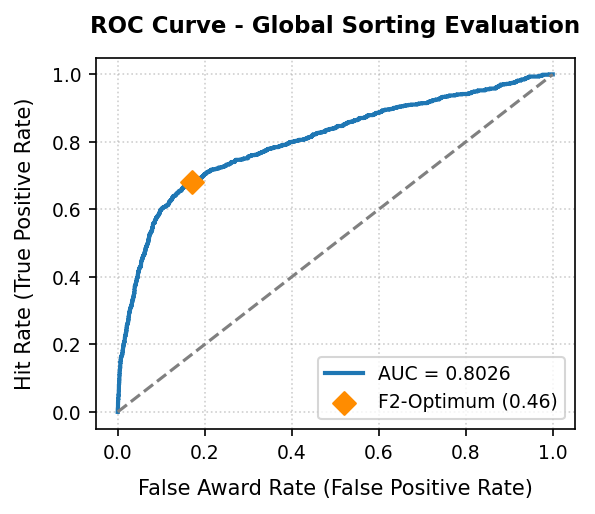

In [88]:

# Calculate the continuous roc curve and auc area

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    proba_test
)

roc_auc = auc(
    fpr,
    tpr
)

# Compute the exact coordinates for the F2 operating point


# Predict hard classes using the validation-selected F2 threshold
y_test_pred_f2 = (proba_test >= best_threshold_f2).astype(int)

# Extract confusion matrix to calculate the rate coordinates mathematically
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_f2).ravel()

# Calculate the precise operational rates
f2_tpr = tp / (tp + fn)  # True Positive Rate (Hit Rate)
f2_fpr = fp / (fp + tn)  # False Positive Rate (False Award Rate)


# Initialize and plot the roc curve

plt.figure(figsize=(4, 3.5), dpi=150)

# Plot the continuous performance curve
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    color='#1f77b4',
    label=f"AUC = {roc_auc:.4f}"
)

# Plot the standard diagonal random classifier baseline
plt.plot([0,1],[0,1]
 ,
    linestyle="--",
    color="gray",
    linewidth=1.5
)


# Place the marker point as a prominent diamond on top of the curve
plt.scatter(
    f2_fpr,
    f2_tpr,
    color='darkorange',
    s=60,
    marker='D',
    zorder=5,
    label=f"F2-Optimum ({best_threshold_f2:.2f})"
)


plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.xlabel(
    "False Award Rate (False Positive Rate)",
    fontsize=10,
    labelpad=8
)

plt.ylabel(
    "Hit Rate (True Positive Rate)",
    fontsize=10,
    labelpad=8
)

plt.title(
    "ROC Curve - Global Sorting Evaluation",
    fontsize=11,
    fontweight="bold",
    pad=12
)

# The legend dynamically displays both the continuous AUC and the F2 marker
plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()

# save
plt.savefig(
    os.path.join(PLOT_DIR, "roc_curve_logreg.png"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


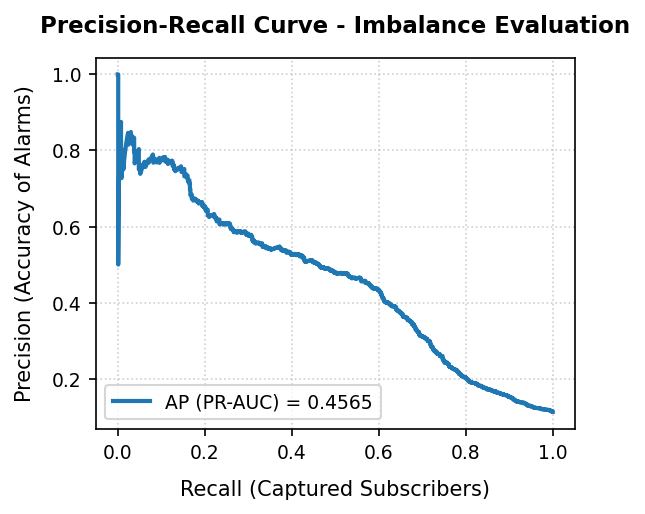

In [61]:
# Precision, Recall arrays and the Average Precision (AP) score
precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba_test)
ap_score = average_precision_score(y_test, proba_test)

# inizialise plot
plt.figure(figsize=(4, 3.5), dpi=150)
plt.plot(recall_vals, precision_vals, color='#1f77b4', linewidth=2, label=f"AP (PR-AUC) = {ap_score:.4f}")


plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel("Recall (Captured Subscribers)", fontsize=10, labelpad=8)
plt.ylabel("Precision (Accuracy of Alarms)", fontsize=10, labelpad=8)
plt.title("Precision-Recall Curve - Imbalance Evaluation", fontsize=11, fontweight='bold', pad=12)
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout()

# Save plot
plt.savefig(
    os.path.join(PLOT_DIR, "precision_recall_curve_logreg.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()


# 11) Model package

In [66]:
model_package = {
    "use_case": "marketing_term_deposit_subscription",
    "model": "logistic_regression_l1_saga",
    "target": TARGET,
    "positive_class": int(POS_LABEL),
    "negative_class": int(NEG_LABEL),
    "output_dir": OUT_DIR,
    "seed": SEED,
    "n_train": int(X_train_poly.shape[0]),
    "n_validation": int(X_val_poly.shape[0]),
    "n_test": int(X_test_poly.shape[0]),
    "n_features_original": int(len(FEATURES)),
    "n_features_polynomial": int(X_train_poly.shape[1]),
    "strategic_budget_cap_percent": 50.0,  # Fixed business constraint defined by management budget limits, can be changed
    "F2-based_budget_cap": best_threshold_f2,
    "primary_metric": "average_precision",
    "secondary_metrics": ["roc_auc"],
    "note": "Optimized L1-LogReg for rank-based probability scoring. Lower grades 1-10 are truncated for efficiency."
}

# Save to a  JSON
with open(os.path.join(OUT_DIR, "model_package.json"), "w", encoding="utf-8") as f:
    json.dump(model_package, f, indent=2)



 # 12) Print summary

In [89]:

print(f"Saved operational outputs to: {OUT_DIR}")
print(f"Saved high-resolution plots to: {PLOT_DIR}")

print(f"Test ROC-AUC (Global Sorting Power):     {roc_auc:.4f}")
print(f"Test PR-AUC  (Global Precision Horizon): {ap_score:.4f}")



Saved operational outputs to: /content/marketing_logreg_results
Saved high-resolution plots to: /content/marketing_logreg_results/plots
Test ROC-AUC (Global Sorting Power):     0.8026
Test PR-AUC  (Global Precision Horizon): 0.4565


In [90]:
comparison_export = pd.DataFrame({
    "y_true": y_test,
    "y_proba": proba_test
})

comparison_export.to_csv(
    "comparison_predictions_logreg.csv",
    index=False
)